### <h1 align="center">Fig. Supplementary 6: Supplementary analysis for the spindle length elongation rate<h1>

This notebook is used to further analyze the spindle length elongation rate as a function of cell size for each embryonic condition. Two linear regression fits are implemented on the dataset of each embryonic condition. The intersection point between the two linear fits is extracted for each embryonic conditions.

**`Input`:**

The input data file is a *.CSV* file for each embryonic condition containing a dynamic analysis summary of all the analyzed experimental dataset. The columns header of each file should look like the following example table below:


|Cell	Vol (µm³) | std_Vol | Cell length (µm) | '...' | segregation speed chromosome-to-chromosome (µm/min) | segregation speed chromosome-to-chromosome std |
| :-----: | :-----: | :-----: |:-----:| :-----: |:----------------------------------------------:|
| `num` | `num` | `num` | `num` | `num` |                     `num`                      |
| `...` | `...` | `...` | `...` | `...` |

**`Output`:**

* *.PNG* file: Plot of spindle length elongation vs cell length for each embryonic condition.
* Two *.CSV* files: One contains the extracted parameters from the linear fitting and the second file contains x- and y-intersection values for all the embryonic conditions.

In [1]:
# library packages
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import t
from sklearn.metrics import r2_score

In [2]:
# input folder
folder = r'E:\data\Analysis Data\01_python_analysis\input'
fileTable = os.listdir(folder)

# # output folder
save_files = r'E:\data\Analysis Data\01_python_analysis\output'

### Load input files

In [3]:
# data loading function
def load_data(folder, fileTable):
    fileList = {}
    
    for file in fileTable:
        filepath = os.path.join(folder, file)
        filename = os.path.basename(filepath)
    
        file_id = [
            '00_Dynamics_analysis_summary (WT).csv',
            '01_Dynamics_analysis_summary (small).csv',
            '01_Dynamics_analysis_summary (big).csv'
        ]
    
        if filename in file_id:
            try:
                df = pd.read_csv(filepath, index_col=None, encoding='utf-8')
            except UnicodeDecodeError:
                df = pd.read_csv(filepath, index_col=None, encoding='cp1252')
            except FileNotFoundError:
                print(f"File not found: {filepath}")
    
            key = filename.replace('.csv', '')
            fileList[key] = df
            
    return fileList


### Assign variables to the loaded input files in the fileList

In [4]:
# create variable of the 
df_wide_type = load_data(folder, fileTable)['00_Dynamics_analysis_summary (WT)']
df_small = load_data(folder, fileTable)['01_Dynamics_analysis_summary (small)']
df_big = load_data(folder, fileTable)['01_Dynamics_analysis_summary (big)']
df_wide_type.columns

Index(['Cell', 'Vol (µm³)', 'std_Vol', 'Cell length (µm)', 'Error propagation',
       'Initial pole-to-pole (µm)', 'Initial pole-to-pole std',
       'Final pole-to-pole (µm)', 'Final pole-to-pole std',
       'Final chromosome-to-chromosome (µm)',
       'Final chromosome-to-chromosome std', 'Final pole-to-chromosome (µm)',
       'Final pole-to-chromosome std', 'Metaphase pole-to-pole (µm)',
       'Metaphase pole-to-pole std', 'Elongation rate pole-to-pole (µm/min)',
       'Elongation rate pole-to-pole std',
       'segregation speed chromosome-to-chromosome (µm/min)',
       'segregation speed chromosome-to-chromosome std'],
      dtype='object')

### Fit two linear regression functions to the input data

In [5]:
def linear_fit_stat_parameters(x_data, y_data, cutoff):

    def fit_stat(x_data, y_data):

        fitresult, cov = np.polyfit(x_data, y_data, 1, cov=True)
        slope = fitresult[0]
        intercept = fitresult[1]

        x_fit = np.linspace(np.min(x_data)-10, np.max(x_data)+10, 500)
        y_fit = np.polyval(fitresult, x_fit)
        
        slope_std = np.sqrt(cov[0, 0])
        t_stat = slope/slope_std
        
        dof = len(x_data) - 2
        p_value = 2*(1 - t.cdf(np.abs(t_stat), dof))
        
        SE_y = np.sqrt(np.sum((y_data - np.polyval(fitresult, x_data))**2) / (len(y_data) - 2))           # standard error of the regression estimate
        SSD = np.sum((x_data - np.mean(x_data))**2)                                                       # sum of squared deviations of x_data from its mean
        SE_x = SE_y * np.sqrt(1/len(x_data) + (x_fit - np.mean(x_data))**2 / SSD)                         # standard errors of each predicted value
        
        ci = t.ppf(0.975, len(x_data) - 2) * SE_x                                                         # confidence interval
        upper_ci = y_fit + ci
        lower_ci = y_fit - ci
        
        SE_slope = SE_y / np.sqrt(SSD)                                                                    # calculate SE for the slope
        t_critical = t.ppf(0.975, len(x_data) - 2)                                                        # get the critical t value
        margin_of_error_slope = t_critical * SE_slope                                                     # calculate the margin of error for the slope
        r_squared = r2_score(y_data, np.polyval(fitresult, x_data))

        return {'x_data': x_data, 
                'y_data': y_data, 
                'fitresult': fitresult, 
                'slope': slope, 
                'intercept': intercept, 
                'slope_std': slope_std, 
                't_stat': t_stat, 
                'p_value': p_value, 
                'x_fit': x_fit, 
                'y_fit': y_fit, 
                'upper_ci': upper_ci, 
                'lower_ci': lower_ci, 
                'SE_slope': SE_slope, 
                'margin_of_error_slope': margin_of_error_slope, 
                'r_squared': r_squared
               }

    # make data threshold cutoff (x = 12)
    mask_upper = x_data > cutoff
    mask_lower = x_data < cutoff

    x_upper = x_data[mask_upper]  # x > cutoff
    y_upper = y_data[mask_upper]
    x_lower = x_data[mask_lower]  # x < cutoff  
    y_lower = y_data[mask_lower]
    
    # fit linear functions to each region
    fit_upper = fit_stat(x_upper, y_upper)
    fit_lower = fit_stat(x_lower, y_lower)

    # find intersection point of the two linear functions
    slope1 = fit_lower['slope']
    intercept1 = fit_lower['intercept']
    slope2 = fit_upper['slope']
    intercept2 = fit_upper['intercept']

    intersection_results = {}
    if abs(slope1 - slope2) > 1e-10:  # Check if slopes are different
        # Solve: slope1*x + intercept1 = slope2*x + intercept2
        x_intersection = (intercept2 - intercept1) / (slope1 - slope2)
        y_intersection = slope1 * x_intersection + intercept1
        intersection_results = {
            'x_intersection': x_intersection,
            'y_intersection': y_intersection,
            'distance_from_cutoff': abs(x_intersection - cutoff)
        }
    else:
        intersection_results = {'parallel_lines': True}

    return fit_upper, fit_lower, slope1, slope2, intersection_results



### Check the returned variables from the fit function

In [6]:
linear_fit_stat_parameters(x_data=df_wide_type['Cell length (µm)'], y_data=df_wide_type['Elongation rate pole-to-pole (µm/min)'], cutoff=12)[4]

{'x_intersection': np.float64(12.538778648879777),
 'y_intersection': np.float64(4.127767103961323),
 'distance_from_cutoff': np.float64(0.5387786488797772)}

### Extract the parameter from the fit function and save to a *.CSV* file

In [7]:
def combined_stat_parameters_df(x_data, y_data, cutoff, save_folder, save_filename):
    x_data = x_data
    y_data = y_data
    parameter_from_fit = linear_fit_stat_parameters(x_data, y_data, cutoff)

    '''upper values'''
    slope_upper_value = parameter_from_fit[0]['slope']
    slope_std_upper_value = parameter_from_fit[0]['slope_std']
    p_value_upper_value = parameter_from_fit[0]['p_value']
    t_stat_upper_value = parameter_from_fit[0]['t_stat']
    r_square_upper_value = parameter_from_fit[0]['r_squared']

    '''lower values'''
    slope_lower_value = parameter_from_fit[1]['slope']
    slope_std_lower_value = parameter_from_fit[1]['slope_std']
    p_value_lower_value = parameter_from_fit[1]['p_value']
    t_stat_lower_value = parameter_from_fit[1]['t_stat']
    r_square_lower_value = parameter_from_fit[1]['r_squared']

    upper_df = pd.DataFrame.from_dict({'Slope': slope_upper_value, 
                                    'Slope std': slope_std_upper_value, 
                                    'P-value': p_value_upper_value, 
                                    't-stat': t_stat_upper_value, 
                                    'R-squared': r_square_upper_value},
                                    orient='index', columns=[f'Cell length > {cutoff} µm'])

    lower_df = pd.DataFrame.from_dict({'Slope': slope_lower_value, 
                                    'Slope std': slope_std_lower_value, 
                                    'P-value': p_value_lower_value, 
                                    't-stat': t_stat_lower_value, 
                                    'R-squared': r_square_lower_value},
                                    orient='index', columns=[f'Cell length < {cutoff} µm'])

    combined_df = pd.concat([lower_df, upper_df], axis=1, ignore_index=False)
    combined_df.index.names = ['Stat parameters']
    combined_df.to_csv(os.path.join(save_folder, save_filename), index=True, encoding='cp1252')

### Extract and save function call

In [8]:
# Wild-type df
WT_combined_stat = combined_stat_parameters_df(df_wide_type['Cell length (µm)'], 
                            df_wide_type['Elongation rate pole-to-pole (µm/min)'], 
                            12, 
                            save_files, 
                            'Combined_statistics_parameters_ELONGATION_RATE (WT).csv'
                            )

# big embryo df
BIG_combined_stat = combined_stat_parameters_df(df_big['Cell length (µm)'], 
                            df_big['Elongation rate pole-to-pole (µm/min)'], 
                            15, 
                            save_files, 
                            'Combined_statistics_parameters_ELONGATION_RATE (BIG).csv'
                            )

# small embryo df
SMALL_combined_stat = combined_stat_parameters_df(df_small['Cell length (µm)'], 
                            df_small['Elongation rate pole-to-pole (µm/min)'], 
                            11.5, 
                            save_files, 
                            'Combined_statistics_parameters_ELONGATION_RATE (SMALL).csv'
                            )

### Extract and save the values of the intersection of the two linear fits at x- and y-axis

In [9]:
def merge_intersection_values(x_data_WT, y_data_WT, cutoff_WT, dataset_type_WT,
                              x_data_BIG, y_data_BIG, cutoff_BIG, dataset_type_BIG,
                              x_data_SMALL, y_data_SMALL, cutoff_SMALL, dataset_type_SMALL,
                              save_folder, save_filename):
 
      def intersection_point_df(x_data, y_data, cutoff, dataset_type):
            parameter_from_fit = linear_fit_stat_parameters(x_data, y_data, cutoff)
            '''intersection point values'''
            x_intersection= parameter_from_fit[4]['x_intersection']
            y_intersection= parameter_from_fit[4]['y_intersection']
            distance_from_cutoff= parameter_from_fit[4]['distance_from_cutoff']
            
            inter_value_df = pd.DataFrame.from_dict({'x_intersection value': x_intersection, 
                                    'y_intersection value': y_intersection, 
                                    'Distance from cutoff': distance_from_cutoff
                                    },
                                    orient='index', columns=[f'{dataset_type}'])
            
            # inter_value_df = pd.DataFrame({
            #       f'{dataset_type}': [x_intersection, y_intersection, distance_from_cutoff]
            #       }, index=['x_intersection value', 'y_intersection value', 'Distance from cutoff'])
            
            return inter_value_df
      
      WT_df =  intersection_point_df(x_data_WT, y_data_WT, cutoff_WT, dataset_type_WT)
      BIG_df =  intersection_point_df(x_data_BIG, y_data_BIG, cutoff_BIG, dataset_type_BIG)
      SMALL_df =  intersection_point_df(x_data_SMALL, y_data_SMALL, cutoff_SMALL, dataset_type_SMALL)
      
      inter_values_merged_table = pd.concat([WT_df, BIG_df, SMALL_df], axis=1, ignore_index=False )
      
      inter_values_merged_table.to_csv(os.path.join(save_folder, save_filename), index=True, encoding='cp1252')


merge_intersection_values(df_wide_type['Cell length (µm)'], df_wide_type['Elongation rate pole-to-pole (µm/min)'], 12, 'WT', 
                          df_big['Cell length (µm)'], df_big['Elongation rate pole-to-pole (µm/min)'], 15, 'BIG',
                          df_small['Cell length (µm)'], df_small['Elongation rate pole-to-pole (µm/min)'], 11.5, 'SMALL',
                          save_files, 'Combined_statistics_intersection_values_ELONGATION_RATE.csv'
                          )

### Plot, visualize and save the fitting

In [10]:
# define plot function for all conditions
def plot_elongation_rate(x_data, x_data_std, y_data, y_data_std, cutoff, color, color_errorbar, plot_filename):
    # fit_upper plot parameters (x > cutoff)
    marker = ['s', 'D', '^', 'o',  'H', 'P', 'p']
    
    x_data = x_data
    x_data_std = x_data_std

    y_data = y_data
    y_data_std = y_data_std

    fit_result = linear_fit_stat_parameters(x_data, y_data, cutoff)
    x_data_fit_plot_upper = fit_result[0]['x_fit']
    y_data_fit_plot_upper = fit_result[0]['y_fit']

    plt.figure(figsize=(7, 7))
    sns.lineplot(x=x_data_fit_plot_upper, y=y_data_fit_plot_upper, color='r')
    # plt.fill_between(x_data_fit_plot_upper, fit_result[0]['lower_ci'], fit_result[0]['upper_ci'], color='#004C99', alpha=0.1, edgecolor=None)
    plt.errorbar(x=x_data, 
                y=y_data, 
                xerr=x_data_std, 
                yerr=y_data_std, 
                capsize=2, 
                elinewidth=1, 
                fmt='none', 
                color=color_errorbar)

    for i, (x_val, y_val) in enumerate(zip(x_data, y_data)):
        marker_idx = i % len(marker)  # cycle through available markers
        plt.scatter(x_val, y_val, marker=marker[marker_idx], color=color, s=150)


    # fit_lower plot parameters (x < 12.0)
    x_data_fit_plot_lower = fit_result[1]['x_fit']
    y_data_fit_plot_lower = fit_result[1]['y_fit']
    sns.lineplot(x=x_data_fit_plot_lower, y=y_data_fit_plot_lower, color='g')
    # plt.fill_between(x_data_fit_plot_lower, fit_result[1]['lower_ci'], fit_result[1]['upper_ci'], color='#004C99', alpha=0.1, edgecolor=None)

    if 'x_intersection' in fit_result[4]:
        plt.scatter(fit_result[4]['x_intersection'],
                    fit_result[4]['y_intersection'],
                    color='purple', s=150, zorder=5, marker='*')

    # plot properties
    plt.xlim(1, 30)
    # plt.ylim(0, 25)
    plt.ylim(1, 8)
    plt.tick_params(axis='both', labelsize=15)
    plt.xlabel('Cell length (µm)', fontsize=25)
    plt.ylabel('Elongation rate (µm/min)', fontsize=25)
    plt.gca().tick_params(axis='both', labelsize=15)
    plt.gca().tick_params(axis='both', which='major', labelsize=15)
    plt.gca().tick_params(axis='both', direction='in', size=12)
    
    # save plot
    plt.savefig(os.path.join(save_files, plot_filename), dpi=600)
    
    return plt


### Call the plot and save function

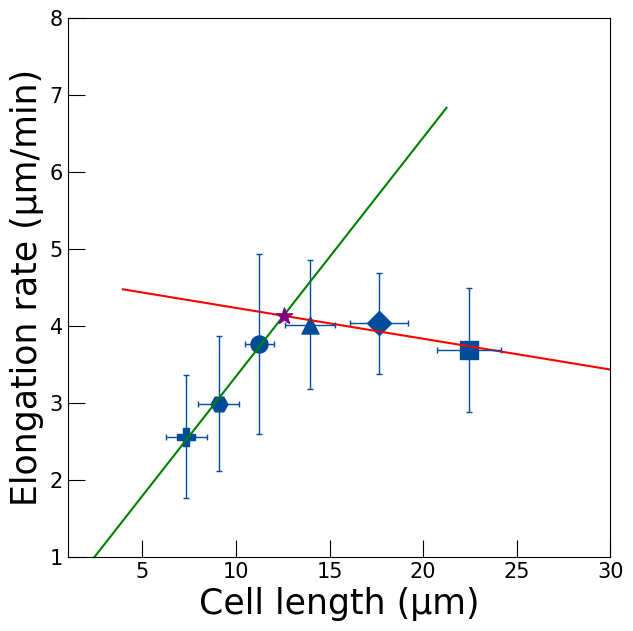

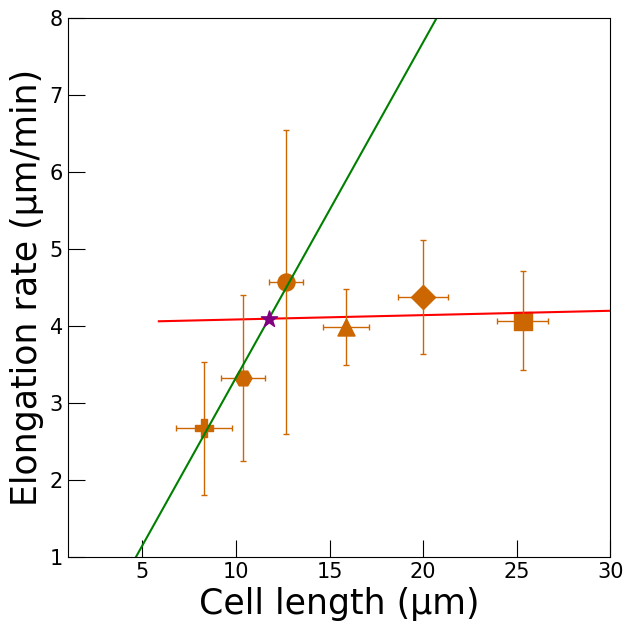

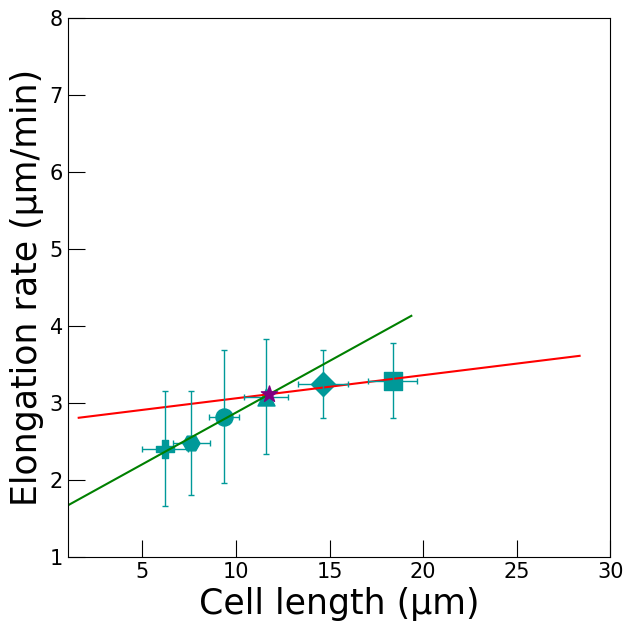

In [11]:
# wide-type plot
WT_plot = plot_elongation_rate(df_wide_type['Cell length (µm)'], 
                            df_wide_type['Error propagation'], 
                            df_wide_type['Elongation rate pole-to-pole (µm/min)'], 
                            df_wide_type['Elongation rate pole-to-pole std'], 
                            12, 
                            '#004C99',
                            '#004C99',
                            'WT_elongation_SUPPLEMENTARY.png'
                            )

# big embryo plot 
BIG_plot = plot_elongation_rate(df_big['Cell length (µm)'], 
                            df_big['Error propagation'], 
                            df_big['Elongation rate pole-to-pole (µm/min)'], 
                            df_big['Elongation rate pole-to-pole std'], 
                            15, 
                            '#CC6600',
                            '#CC6600',
                            'BIG_elongation_SUPPLEMENTARY.png'
                            )
# smalll embryo plot 
SMALL_plot = plot_elongation_rate(df_small['Cell length (µm)'], 
                            df_small['Error propagation'], 
                            df_small['Elongation rate pole-to-pole (µm/min)'], 
                            df_small['Elongation rate pole-to-pole std'], 
                            11.5, 
                            '#009999',
                            '#009999',
                            'SMALL_elongation_SUPPLEMENTARY.png'
                            )